# Mini-Project 2
## Lecture 4 - Multiprocessing
### Lecture 4 - Milestone 1

Text(0, 0.5, 'Im(c)')

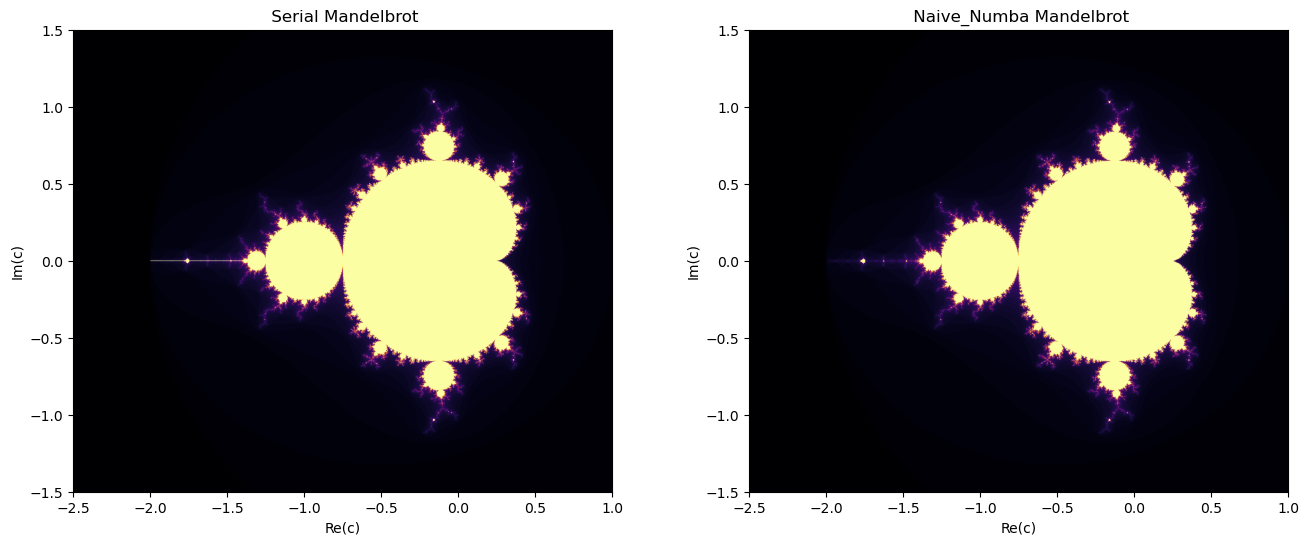

In [1]:
import numpy as np
from numba import njit
from multiprocessing import Pool
import time, os, statistics, matplotlib.pyplot as plt
from pathlib import Path
from mandelbrot_3 import benchmark, compute_mandelbrot_full
from mandelbrot_4 import mandelbrot_serial

# Parameters
iterations = 100
N = 1024
x_dim = (-2.5, 1.0)
y_dim = (-1.5, 1.5)
resolution = (1024, 1024)

#Numba and serial compared
result_full = compute_mandelbrot_full(x_dim=x_dim, y_dim=y_dim, res=resolution, max_iter=iterations)
result_serial = mandelbrot_serial(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=iterations)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].imshow(result_serial, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[0].set_title(' Serial Mandelbrot')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')

axes[1].imshow(result_full, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[1].set_title(' Naive_Numba Mandelbrot')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')

### Lecture 4 - Milestone 2

Text(0, 0.5, 'Im(c)')

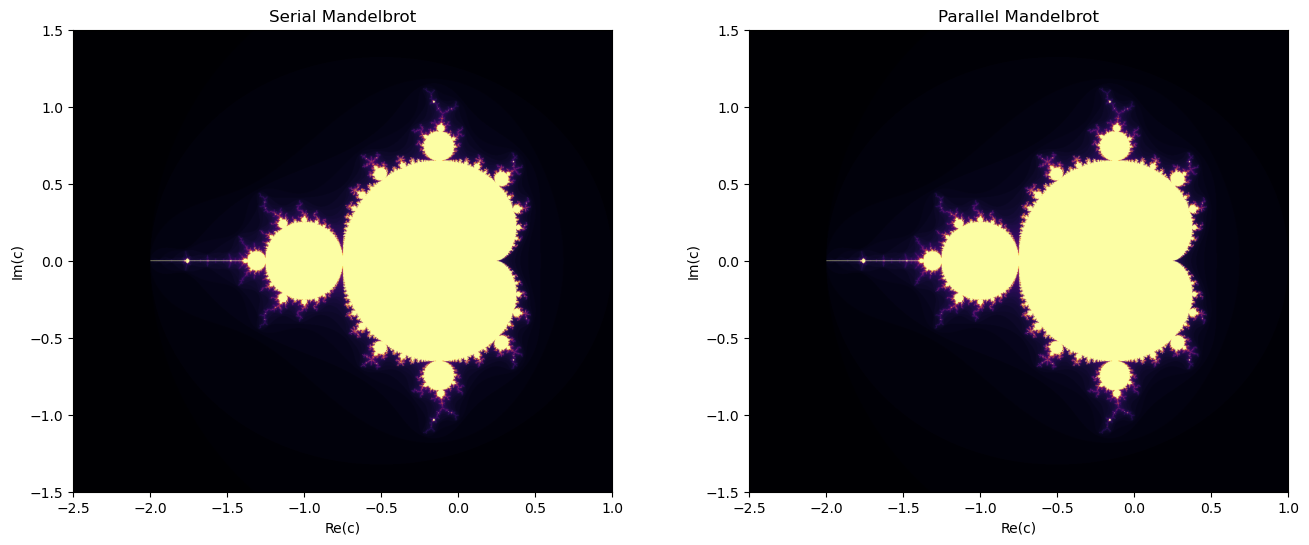

In [2]:
from mandelbrot_4 import mandelbrot_parallel, _worker    

# Parameters
n_workers = 4

# Milestone 2 testing:
result_serial = mandelbrot_serial(N=N, x_dim=x_dim, y_dim=y_dim)
result_parallel = mandelbrot_parallel(N=N, x_dim=x_dim, y_dim=y_dim, num_workers=n_workers)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].imshow(result_serial, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[0].set_title('Serial Mandelbrot')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')

axes[1].imshow(result_parallel, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[1].set_title('Parallel Mandelbrot')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')

### Lecture 4 - Milestone 3

 1 workers | parallel time: 0.0762s | speedup: 0.79x | efficiency: 0.79
 2 workers | parallel time: 0.0470s | speedup: 1.28x | efficiency: 0.64
 3 workers | parallel time: 0.0550s | speedup: 1.10x | efficiency: 0.37
 4 workers | parallel time: 0.0419s | speedup: 1.44x | efficiency: 0.36
 5 workers | parallel time: 0.0429s | speedup: 1.41x | efficiency: 0.28
 6 workers | parallel time: 0.0465s | speedup: 1.30x | efficiency: 0.22
 7 workers | parallel time: 0.0637s | speedup: 0.95x | efficiency: 0.14
 8 workers | parallel time: 0.0260s | speedup: 2.32x | efficiency: 0.29
speedup_peak=2.32, n_workers_peak=8
 Implied s: 0.35


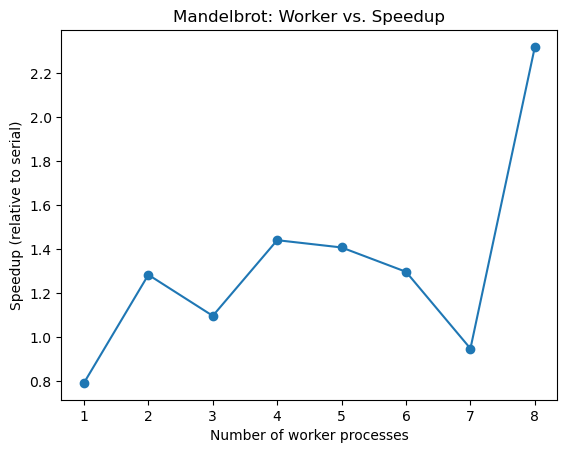

<Figure size 640x480 with 0 Axes>

In [3]:
from monte_carlo_example import plot_worker_speedup

# Parameters
n_runs = 3

workers_list = []
speedups = []

# Serial baseline (Numba already warm after M1 warm-up)
times = []
for _ in range(n_runs):
    start_time = time.perf_counter()
    mandelbrot_serial(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=iterations)
    times.append(time.perf_counter() - start_time)
t_serial = statistics.median(times)

for n_workers in range(1, os.cpu_count() + 1):
    chunk_size = max(1, N // n_workers)
    chunks = []
    row = 0
    while row < N:
        row_end = min(row + chunk_size, N) # determine end of the row
        chunks.append((row, row_end, N, x_dim, y_dim, iterations))
        row = row_end

    with Pool(processes=n_workers) as pool:
        pool.map(_worker, chunks)
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            np.vstack(pool.map(_worker, chunks))
            times.append(time.perf_counter() - t0)
    t_parallel = statistics.median(times)
    speedup = t_serial / t_parallel

    # Append workers and speedups for plotting
    workers_list.append(n_workers)
    speedups.append(speedup)

    # print table of workers, speedup and efficiency
    print(f'{n_workers:2d} workers | '
            f'parallel time: {t_parallel:.4f}s | '
            f'speedup: {speedup:.2f}x | '
            f'efficiency: {speedup/n_workers:.2f}')

# get peak for computing the implied s
index_peak = np.argmax(speedups)
speedup_peak = speedups[index_peak]        # optimal speedup
n_workers_peak = workers_list[index_peak]  # optimal number of workers
print(f'{speedup_peak=:.2f}, {n_workers_peak=}')

s_4 = (1/speedup_peak - 1/n_workers_peak) / (1 - 1/n_workers_peak)
print(f' Implied s: {s_4:.2f}')

# Plot worker vs. speedup
plot_worker_speedup(title="Mandelbrot", workers=workers_list, speedup=speedups)
plt.savefig("figures/Mandelbrot_worker_speedup.png")

## Lecture 5 - Multiprocessing + Dask
### Lecture 5 - Milestone 1
Verify result matches serial output for n_chunks 

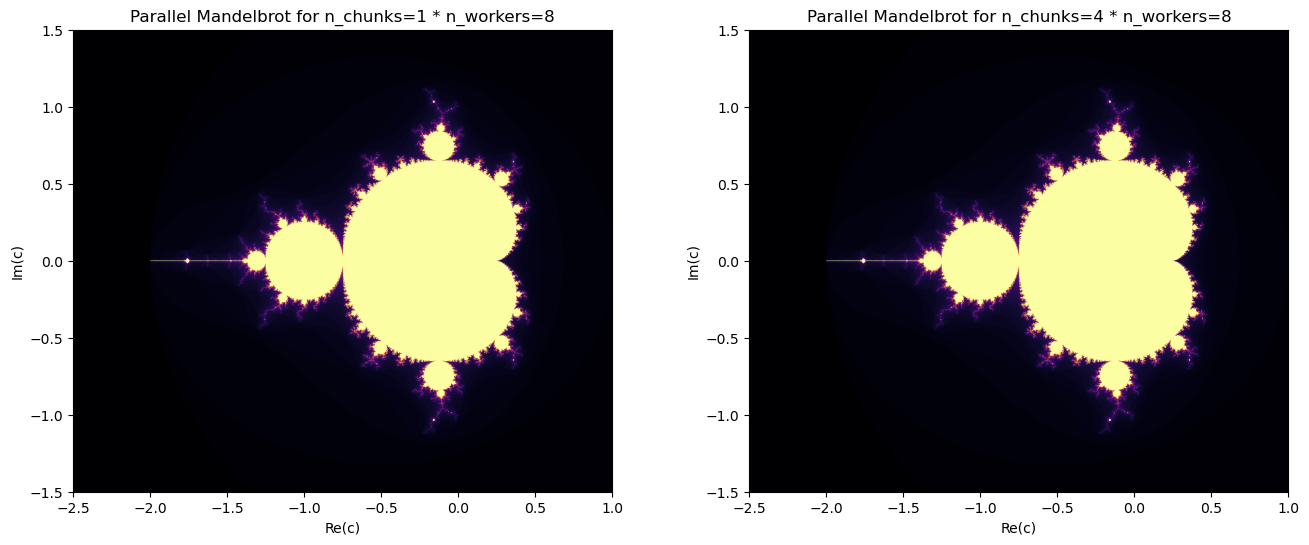

In [4]:
from mandelbrot_5 import mandelbrot_parallel

# Milestone 1 testing:
n_chunks = 4

result_parallel_1nchunk = mandelbrot_parallel(N=N, x_dim=x_dim, y_dim=y_dim, num_workers=n_workers, n_chunks=1*n_workers)
result_parallel_4nchunks = mandelbrot_parallel(N=N, x_dim=x_dim, y_dim=y_dim, num_workers=n_workers, n_chunks=n_chunks*n_workers)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].imshow(result_parallel_1nchunk, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[0].set_title(f'Parallel Mandelbrot for n_chunks=1 * {n_workers=}')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')

axes[1].imshow(result_parallel_4nchunks, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
axes[1].set_title(f'Parallel Mandelbrot for {n_chunks=} * {n_workers=}')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')
plt.show()

### Lecture 5 - Milestone 2
Record optimal n_chunks and LIF in performance notebook (MP2)

In [5]:
from mandelbrot_5 import mandelbrot_chunk

# Parameters
N = 1024
iterations = 100
n_workers = n_workers_peak
x_dim = (-2.5, 1.0)
y_dim = (-1.25, 1.25)
n_runs = 3

mandelbrot_chunk(row_start=0, row_end=8, N=8, x_dim=x_dim, y_dim=y_dim, max_iter=iterations) # warm up JIT

# Serial baseline
times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    mandelbrot_chunk(row_start=0, row_end=N, N=N, x_dim=x_dim, y_dim=y_dim, max_iter=iterations)
    times.append(time.perf_counter() - t0)
t_serial = statistics.median(times)
print(f'Serial: {t_serial:.3f}s')

print(f"{'Num Chunks':>12} | {'Parallel Time':>12} (s) | {'Speedup':>8} (x) | {'LIF':>8} |")

# Chunk-count sweep (M2): one Pool per config
t_parallel_arr = []
tiny = [(0, 8, 8, x_dim, y_dim, iterations)]
for mult in [1, 2, 4, 8, 16]:
    n_chunks = mult * n_workers
    with Pool(processes=n_workers) as pool:
        pool.map(_worker, tiny)         # warm-up: load JIT cache in workers
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            mandelbrot_parallel(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=iterations, num_workers=n_workers, n_chunks=n_chunks, pool=pool)
            times.append(time.perf_counter() - t0)
    t_parallel = statistics.median(times)
    t_parallel_arr.append(t_parallel)   # create array for getting minimum t_parallel
    lif_parallel = n_workers * t_parallel / t_serial - 1

    print(f'{n_chunks:12d} | {t_parallel:17.3f} | {t_serial/t_parallel:12.1f} | {lif_parallel:>8.2f} |')


Serial: 0.095s
  Num Chunks | Parallel Time (s) |  Speedup (x) |      LIF |
           8 |             0.031 |          3.1 |     1.61 |
          16 |             0.033 |          2.9 |     1.80 |
          32 |             0.027 |          3.6 |     1.24 |
          64 |             0.027 |          3.6 |     1.24 |
         128 |             0.029 |          3.3 |     1.43 |


### Lecture 5 - Milestone 3
Record all results (for all implementations) in performance notebook (MP2)
Speedup table:

In [6]:
# Import mandelbrot naive, numpy, numba and parallel
from mandelbrot_1_2 import compute_mandelbrot_naive, compute_mandelbrot_numpy
from mandelbrot_3 import compute_mandelbrot_full
#from mandelbrot_5 import mandelbrot_parallel

warmup_res = (64, 64)
resolution = (1024, 1024)
N = 1024
iterations = 100

# 1: Speedup table:
print(f'1. Speedup Table:\n',
      f"{'Implementation':>12} | {'Time (s)':>12} | {'Speedup (x)':>12} |")

# Naive Implementation
times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    compute_mandelbrot_naive(x_dim=x_dim, y_dim=y_dim, res=resolution)
    times.append(time.perf_counter() - t0)
t_naive = statistics.median(times)
speedup_naive = t_naive/t_naive
print(f"{'Naive Python':>15} | {t_naive:12.3f} | {speedup_naive:12.2f} |")

# Numpy baseline
times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    compute_mandelbrot_numpy(x_dim=x_dim, y_dim=y_dim, res=resolution)
    times.append(time.perf_counter() - t0)
t_numpy = statistics.median(times)
speedup_numpy = t_naive/t_numpy
print(f"{'Numpy':>15} | {t_numpy:12.3f} | {speedup_numpy:12.2f} |")

# Numba baseline
times = []
_ = compute_mandelbrot_full(x_dim=x_dim, y_dim=y_dim, res=warmup_res)  # warmup JIT 
for _ in range(n_runs):
    t0 = time.perf_counter()
    compute_mandelbrot_full(x_dim=x_dim, y_dim=y_dim, res=resolution, max_iter=iterations)
    times.append(time.perf_counter() - t0)
t_numba = statistics.median(times)
speedup_numba = t_naive/t_numba
print(f"{'Numba @njit':>15} | {t_numba:12.3f} | {speedup_numba:12.2f} |")

# Parallel baseline (t_parallel from Milestone 1)
index_t_parallel_peak = np.argmin(t_parallel_arr)
t_parallel = t_parallel_arr[index_t_parallel_peak] # optimal t_parallel
speedup_parallel = t_naive/t_parallel
print(f"{'Parallel (opt)':>15} | {t_parallel:12.3f} | {speedup_parallel:12.2f} |") 


# Back-solve implied:
speedup_parallel_numba = t_numba/t_parallel
print(f'{speedup_parallel_numba=}, {n_workers=}')
s_5 = (1/speedup_parallel_numba - 1/n_workers) / (1 - 1/n_workers)

print('\n2. Speedup vs. core count')
print(f'Implied s (L4): {s_4}')
print(f'Implied s (L5): {s_5}')




1. Speedup Table:
 Implementation |     Time (s) |  Speedup (x) |
   Naive Python |       12.308 |         1.00 |
          Numpy |        2.372 |         5.19 |
    Numba @njit |        0.081 |       152.62 |
 Parallel (opt) |        0.027 |       461.96 |
speedup_parallel_numba=3.026918685849587, n_workers=8

2. Speedup vs. core count
Implied s (L4): 0.3500969750516992
Implied s (L5): 0.23470739106966423


#### 3. Brief Recommendation:
Parallel with n_chunks of 2-4x n_workers results in best speedup at 0.022 s giving a speedup of 448x compared to the naive approach. Compared to numba it is approx 3.5x speedup. 
The Back-solve implied s, is approx the same as in L04, while LIF is 1.3 at n_chunks=16  

## Lecture 6 - DASK (Distributed Computing)
### Lecture 6 - Milestone 1


In [ ]:
from mandelbrot_5 import mandelbrot_chunk
from mandelbrot_6 import mandelbrot_dask
from mandelbrot_1_2 import compute_mandelbrot_naive
from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, time, statistics

N = 1024
res = (N, N)
max_iter = 100
n_runs = 3

x_dim = (-2.5, 1.0)
y_dim = (-1.25, 1.25)
cluster = LocalCluster(n_workers=8, threads_per_worker=1)
client = Client(cluster)
client.run(lambda: mandelbrot_chunk(row_start=0, row_end=8, N=8, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter))

times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    mandelbrot_dask(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter)
    times.append(time.perf_counter() - t0)
    time_dask = statistics.median(times)
print(f"Dask local (n_chunks=32): {time_dask:.3f} s")
client.close(); cluster.close()

times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    compute_mandelbrot_naive(x_dim=x_dim, y_dim=y_dim, res=res)
    times.append(time.perf_counter() - t0)
    time_naive = statistics.median(times)
print(f'Naive: {time_naive} s')
print(f"Speedup: {time_naive/time_dask:.3f} x")



Dask local (n_chunks=32): 0.190 s


2026-03-25 23:56:16,333 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:63110'.


Naive: 8.605761500017252 s
Speedup: 45.300 x


### Lecture 6 - Milestone 2
Find the optimal chunk count for Dask local on your machine.
Record n chunks optimal and LIF min in performance notebook (MP2) → commit

c:\Users\mathi\miniforge3\envs\nsc2026\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 61697 instead
  warnings.warn(


Chunks:   1 | Time: 0.32s | Speedup: 1.00 | LIF: 0.00
Chunks:   2 | Time: 0.13s | Speedup: 2.41 | LIF: -0.17
Chunks:   4 | Time: 0.23s | Speedup: 1.38 | LIF: 1.89
Chunks:   8 | Time: 0.08s | Speedup: 4.21 | LIF: 0.90
Chunks:  16 | Time: 0.15s | Speedup: 2.13 | LIF: 6.51
Chunks:  32 | Time: 0.23s | Speedup: 1.40 | LIF: 21.80
Chunks:  64 | Time: 0.31s | Speedup: 1.04 | LIF: 60.82
Chunks: 128 | Time: 0.48s | Speedup: 0.67 | LIF: 190.90


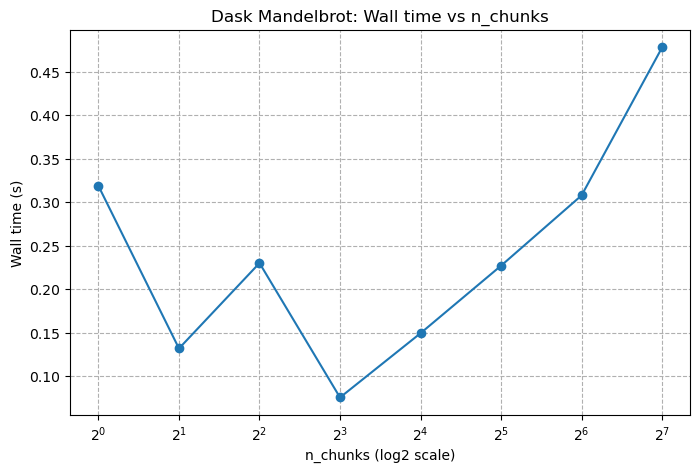

Optimal n_chunks: 8, t_min: 0.08s, LIF_min: 0.90


In [2]:
from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, time, statistics
import numpy as np
import matplotlib.pyplot as plt
from mandelbrot_5 import mandelbrot_chunk
from mandelbrot_6 import mandelbrot_dask

# Sweep over n_chunks
N = 1024 
n_runs = 3
x_dim = (-2.0, 1.0)
y_dim = (-1.5, 1.5)
max_iter = 100
chunk_values = [1, 2, 4, 8, 16, 32, 64, 128]  # n_chunks to sweep over

cluster = LocalCluster(n_workers=8, threads_per_worker=1)
client = Client(cluster)
client.run(lambda: mandelbrot_chunk(row_start=0, row_end=8, N=8, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter)) # warmup clients

results = []

for n_chunks in chunk_values:
    run_times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        mandelbrot_dask(N, x_dim, y_dim, max_iter, n_chunks=n_chunks)
        run_times.append(time.perf_counter() - start)
    median_time = statistics.median(run_times)
    if n_chunks == 1:
        T1 = median_time  # baseline
        speedup = 1.0
        LIF = 0.0
    else:
        speedup = T1 / median_time
        LIF = n_chunks * median_time / T1 - 1
    results.append((n_chunks, median_time, speedup, LIF))
    print(f"Chunks: {n_chunks:3d} | Time: {median_time:.2f}s | Speedup: {speedup:.2f} | LIF: {LIF:.2f}")

# Convert results to arrays for plotting
results_array = np.array(results)
n_chunks_arr = results_array[:,0]
times_arr = results_array[:,1]
speedup_arr = results_array[:,2]
LIF_arr = results_array[:,3]

# Plot wall time vs n_chunks
plt.figure(figsize=(8,5))
plt.plot(n_chunks_arr, times_arr, marker='o')
plt.xscale('log', base=2)
plt.xlabel("n_chunks (log2 scale)")
plt.ylabel("Wall time (s)")
plt.title("Dask Mandelbrot: Wall time vs n_chunks")
plt.grid(True, which='both', ls='--')
plt.savefig("figures/dask_chunk_sweep.png", dpi=150)
plt.show()

# Find optimal chunk count
optimal_idx = np.argmin(times_arr)
n_optimal = int(n_chunks_arr[optimal_idx])
t_min = times_arr[optimal_idx]
LIF_min = LIF_arr[optimal_idx]

print(f"Optimal n_chunks: {n_optimal}, t_min: {t_min:.2f}s, LIF_min: {LIF_min:.2f}")